In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

plt.style.use("dark_background")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
df = pd.read_csv("01_District_wise_crimes_committed_IPC_2001_2012.csv")

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,STATE/UT,DISTRICT,YEAR,MURDER,ATTEMPT TO MURDER,CULPABLE HOMICIDE NOT AMOUNTING TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,...,ARSON,HURT/GREVIOUS HURT,DOWRY DEATHS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,INSULT TO MODESTY OF WOMEN,CRUELTY BY HUSBAND OR HIS RELATIVES,IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES,CAUSING DEATH BY NEGLIGENCE,OTHER IPC CRIMES,TOTAL IPC CRIMES
0,ANDHRA PRADESH,ADILABAD,2001,101,60,17,50,0,50,46,...,30,1131,16,149,34,175,0,181,1518,4154
1,ANDHRA PRADESH,ANANTAPUR,2001,151,125,1,23,0,23,53,...,69,1543,7,118,24,154,0,270,754,4125
2,ANDHRA PRADESH,CHITTOOR,2001,101,57,2,27,0,27,59,...,38,2088,14,112,83,186,0,404,1262,5818
3,ANDHRA PRADESH,CUDDAPAH,2001,80,53,1,20,0,20,25,...,23,795,17,126,38,57,0,233,1181,3140
4,ANDHRA PRADESH,EAST GODAVARI,2001,82,67,1,23,0,23,49,...,41,1244,12,109,58,247,0,431,2313,6507


In [4]:
print("Shape:", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nMissing Values:\n")
print(df.isnull().sum())

Shape: (9017, 33)

Columns:

Index(['STATE/UT', 'DISTRICT', 'YEAR', 'MURDER', 'ATTEMPT TO MURDER',
       'CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'RAPE', 'CUSTODIAL RAPE',
       'OTHER RAPE', 'KIDNAPPING & ABDUCTION',
       'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DACOITY',
       'PREPARATION AND ASSEMBLY FOR DACOITY', 'ROBBERY', 'BURGLARY', 'THEFT',
       'AUTO THEFT', 'OTHER THEFT', 'RIOTS', 'CRIMINAL BREACH OF TRUST',
       'CHEATING', 'COUNTERFIETING', 'ARSON', 'HURT/GREVIOUS HURT',
       'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES',
       'CAUSING DEATH BY NEGLIGENCE', 'OTHER IPC CRIMES', 'TOTAL IPC CRIMES'],
      dtype='str')

Missing Values:

STATE/UT                                               0
DISTRICT                                               0
YEAR    

In [5]:
df.columns = df.columns.str.strip()

df.fillna(0, inplace=True)

print("Dataset Cleaned Successfully")

Dataset Cleaned Successfully


In [6]:
crime_columns = df.columns[5:]

df["TOTAL_CRIME"] = df[crime_columns].sum(axis=1)

df[["STATE/UT", "DISTRICT", "YEAR", "TOTAL_CRIME"]].head()

,STATE/UT,DISTRICT,YEAR,TOTAL_CRIME
0,ANDHRA PRADESH,ADILABAD,2001,8442
1,ANDHRA PRADESH,ANANTAPUR,2001,8416
2,ANDHRA PRADESH,CHITTOOR,2001,12287
3,ANDHRA PRADESH,CUDDAPAH,2001,6365
4,ANDHRA PRADESH,EAST GODAVARI,2001,13958


In [7]:
top_states = (
    df.groupby("STATE/UT")["TOTAL_CRIME"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_states

STATE/UT
MAHARASHTRA       10166820
MADHYA PRADESH    10163176
ANDHRA PRADESH     8611388
TAMIL NADU         8562086
UTTAR PRADESH      7961112
RAJASTHAN          7908290
KARNATAKA          6277680
GUJARAT            5968730
KERALA             5875098
BIHAR              5628276
Name: TOTAL_CRIME, dtype: int64

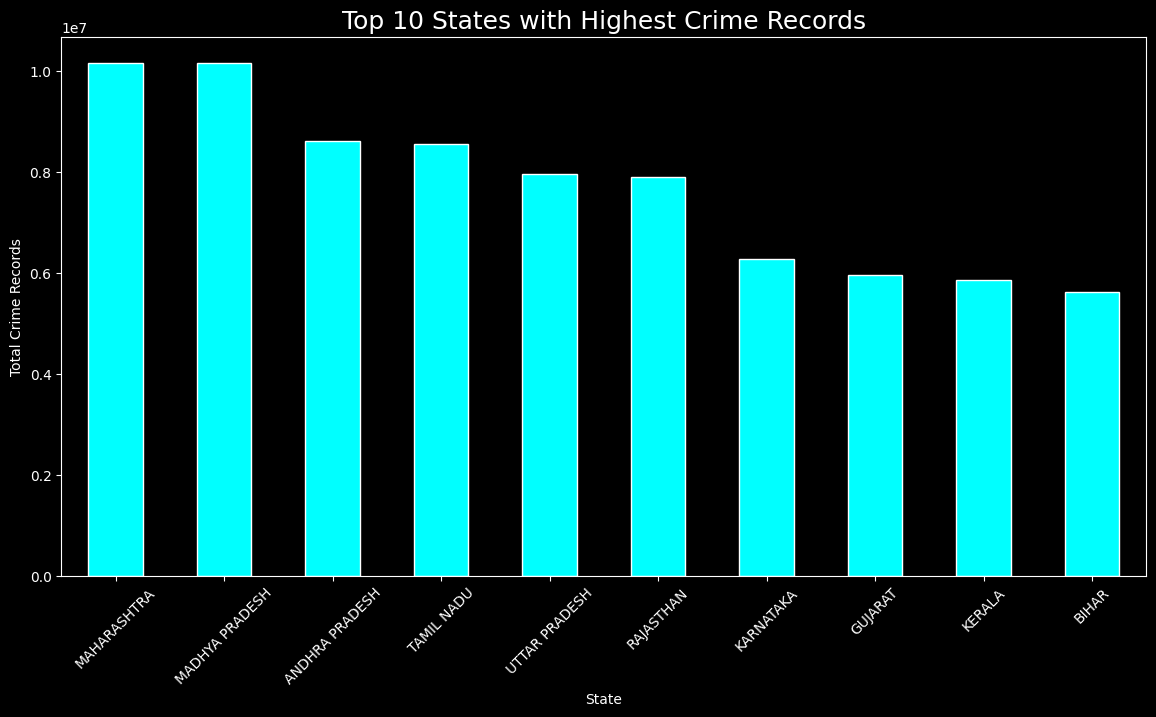

In [8]:
plt.figure(figsize=(14, 7))

top_states.plot(
    kind="bar",
    color="cyan",
    edgecolor="white"
)

plt.title("Top 10 States with Highest Crime Records", fontsize=18)
plt.xlabel("State")
plt.ylabel("Total Crime Records")

plt.xticks(rotation=45)

plt.show()

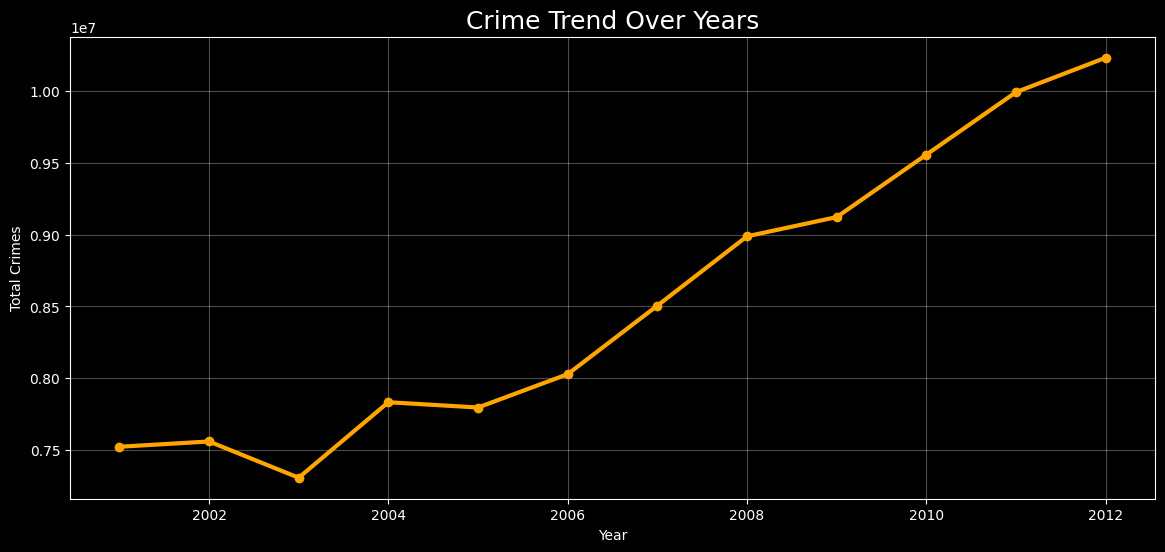

In [9]:
yearly_trend = (
    df.groupby("YEAR")["TOTAL_CRIME"]
    .sum()
)

plt.figure(figsize=(14, 6))

plt.plot(
    yearly_trend.index,
    yearly_trend.values,
    marker="o",
    linewidth=3,
    color="orange"
)

plt.title("Crime Trend Over Years", fontsize=18)
plt.xlabel("Year")
plt.ylabel("Total Crimes")

plt.grid(alpha=0.3)

plt.show()

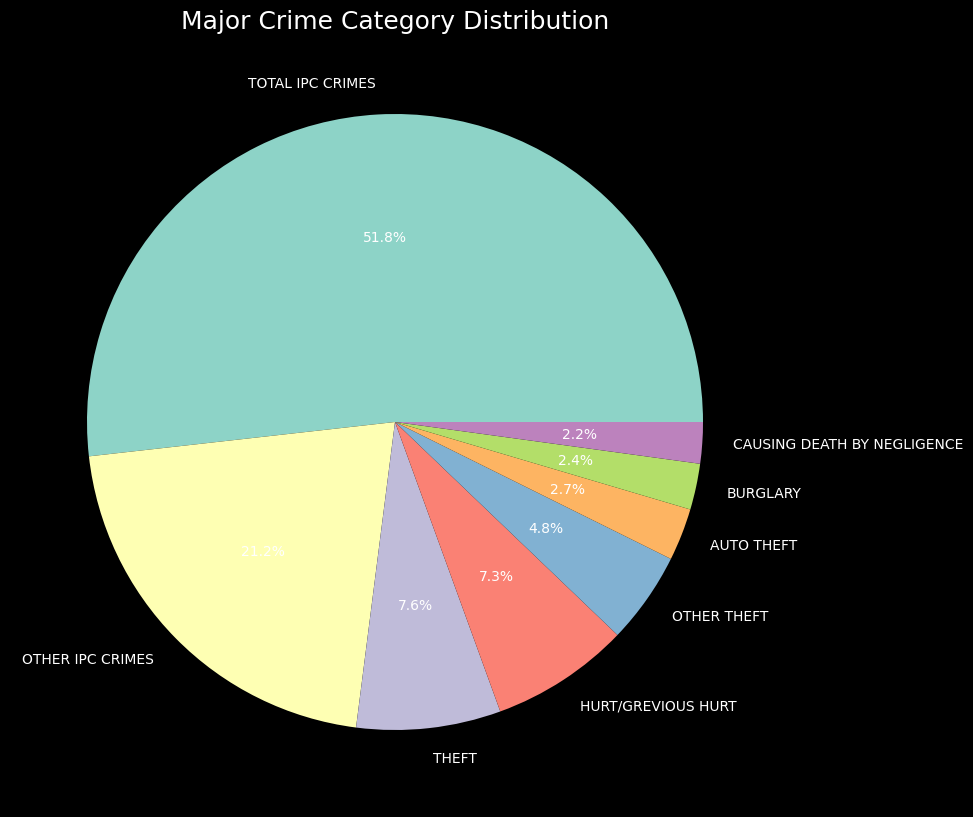

In [10]:
crime_totals = df[crime_columns].sum().sort_values(ascending=False).head(8)

plt.figure(figsize=(10, 10))

plt.pie(
    crime_totals.values,
    labels=crime_totals.index,
    autopct="%1.1f%%",
)

plt.title("Major Crime Category Distribution", fontsize=18)

plt.show()

In [11]:
most_dangerous_state = top_states.idxmax()

highest_crime_value = int(top_states.max())

fastest_growth_year = yearly_trend.diff().idxmax()

crime_insight = {
    "most_dangerous_state": most_dangerous_state,
    "highest_crime_records": highest_crime_value,
    "fastest_growth_year": int(fastest_growth_year),
    "insight": f"{most_dangerous_state} recorded the highest crime activity with {highest_crime_value:,} total cases. Crime growth peaked around {fastest_growth_year}."
}

crime_insight

{'most_dangerous_state': 'MAHARASHTRA',
 'highest_crime_records': 10166820,
 'fastest_growth_year': 2004,
 'insight': 'MAHARASHTRA recorded the highest crime activity with 10,166,820 total cases. Crime growth peaked around 2004.'}

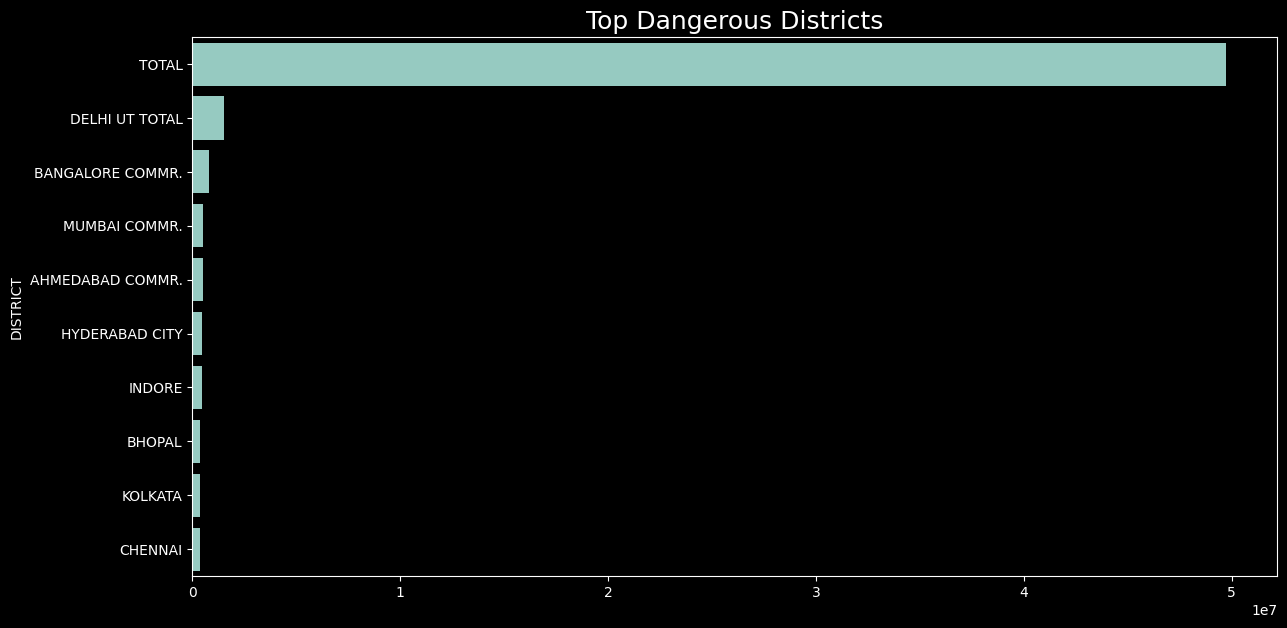

In [12]:
district_crime = (
    df.groupby("DISTRICT")["TOTAL_CRIME"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14, 7))

sns.barplot(
    x=district_crime.values,
    y=district_crime.index
)

plt.title("Top Dangerous Districts", fontsize=18)

plt.show()

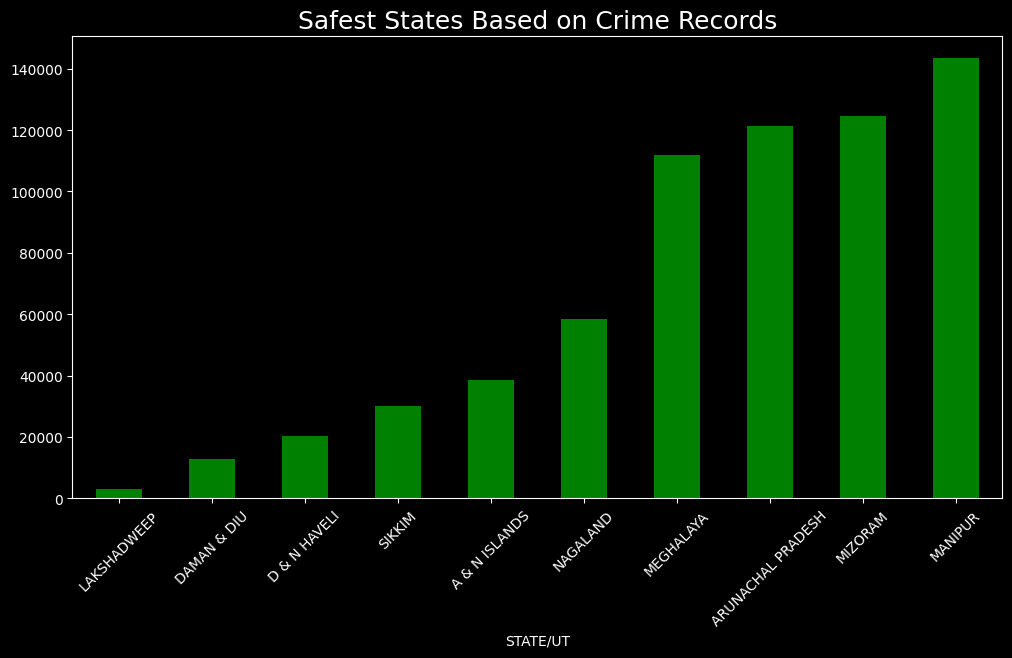

In [13]:
safe_states = (
    df.groupby("STATE/UT")["TOTAL_CRIME"]
    .sum()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(12, 6))

safe_states.plot(
    kind="bar",
    color="green"
)

plt.title("Safest States Based on Crime Records", fontsize=18)

plt.xticks(rotation=45)

plt.show()

In [14]:
top_states_dict = top_states.to_dict()

yearly_trend_dict = yearly_trend.to_dict()

export_data = {
    "top_states": top_states_dict,
    "yearly_trend": yearly_trend_dict,
    "crime_insight": crime_insight
}

with open("crime_records_processed.json", "w") as f:
    json.dump(export_data, f)

print("JSON Exported Successfully")

JSON Exported Successfully
